In [1]:
import anndata
import torch
import stPlus

import squidpy as sq
import numpy as np
import scanpy as sc
import pandas as pd

from scipy import sparse
from sklearn.model_selection import KFold
from transpa.eval_util import calc_corr
from transpa.util import expTransImp, leiden_cluster, compute_autocorr, expLocImp
from benchmark import SpaGE_impute, Tangram_impute
import warnings
from sklearn.preprocessing import MinMaxScaler
torch.autograd.detect_anomaly()
warnings.filterwarnings('ignore')

seed = 10
device = torch.device("cuda:3") if torch.cuda.is_available() else torch.device("cpu")

In [2]:
spatial_df_file = '../../data/ST/osmFISH/osmFISH_df.csv'
spatial_loom_file = '../../data/ST/osmFISH/osmFISH_SScortex_mouse_all_cells.loom'

VISp_adata = sc.read("../../data/scRNAseq/Allen_VISp/mouse_VISp_2018-06-14_exon-matrix.csv").T
genes = pd.read_csv("../../data/scRNAseq/Allen_VISp/mouse_VISp_2018-06-14_genes-rows.csv", header=0,sep=',')
VISp_meta = pd.read_csv("../../data/scRNAseq/Allen_VISp/mouse_VISp_2018-06-14_samples-columns.csv", header=0,sep=',')

VISp_adata.obs = VISp_meta
VISp_adata.var_names = genes.gene_symbol

sc.pp.filter_genes(VISp_adata, min_cells=10)
VISp_adata = VISp_adata[(VISp_adata.obs['class'] != 'No Class') & (VISp_adata.obs['class'] != 'Low Quality')]
classes, ct_list = leiden_cluster(VISp_adata)
cls_key = 'leiden'
VISp_adata.obs[cls_key] = classes
sc.pp.normalize_total(VISp_adata)
sc.pp.log1p(VISp_adata)
VISp_adata


AnnData object with n_obs × n_vars = 14249 × 34617
    obs: 'sample_name', 'sample_id', 'sample_type', 'organism', 'donor', 'sex', 'age_days', 'eye_condition', 'genotype', 'driver_lines', 'reporter_lines', 'brain_hemisphere', 'brain_region', 'brain_subregion', 'injection_label_direction', 'injection_primary', 'injection_secondary', 'injection_tract', 'injection_material', 'injection_exclusion_criterion', 'facs_date', 'facs_container', 'facs_sort_criteria', 'rna_amplification_set', 'library_prep_set', 'library_prep_avg_size_bp', 'seq_name', 'seq_tube', 'seq_batch', 'total_reads', 'percent_exon_reads', 'percent_intron_reads', 'percent_intergenic_reads', 'percent_rrna_reads', 'percent_mt_exon_reads', 'percent_reads_unique', 'percent_synth_reads', 'percent_ecoli_reads', 'percent_aligned_reads_total', 'complexity_cg', 'genes_detected_cpm_criterion', 'genes_detected_fpkm_criterion', 'tdt_cpm', 'gfp_cpm', 'class', 'subclass', 'cluster', 'confusion_score', 'cluster_correlation', 'core_intermed

In [3]:
osmFISH = sc.read_loom(spatial_loom_file)
osmFISH = osmFISH[~np.isin(osmFISH.obs.Region, ['Excluded', 'Hippocampus', 'Internal Capsule Caudoputamen','Ventricle', 'White matter'])].copy()
raw_spatial_df  = pd.read_csv(spatial_df_file)
osmFISH.X = raw_spatial_df.values


raw_scrna_df    = pd.DataFrame(VISp_adata.X, columns=VISp_adata.var_names)
adata_scrna   = VISp_adata

raw_shared_gene = np.intersect1d(raw_spatial_df.columns, raw_scrna_df.columns)
raw_spatial_df.shape, raw_scrna_df.shape, raw_shared_gene.shape

((3405, 33), (14249, 34617), (33,))

In [4]:
osmFISH.obsm['spatial'] = MinMaxScaler().fit_transform(np.hstack([osmFISH.obs.X.values.reshape(-1,1), osmFISH.obs.Y.values.reshape(-1,1)]))


2022-12-23 10:46:25,626 - harmonypy - INFO - Iteration 1 of 10
2022-12-23 10:46:35,134 - harmonypy - INFO - Iteration 2 of 10
2022-12-23 10:46:44,418 - harmonypy - INFO - Converged after 2 iterations


tensor([0.1310, 0.1929, 0.1265, 0.2117, 0.1634, 0.2013, 0.4292, 0.1520, 0.1157,
        0.2858, 0.1874, 0.1307, 0.1061, 0.4048, 0.1877, 0.1366, 0.4450, 0.4541,
        0.1322, 0.1096, 0.1334, 0.3336, 0.0967, 0.7275, 0.1861, 0.1441, 0.1833,
        0.5212, 0.2621, 0.0969, 0.1077, 0.1095, 0.1636], device='cuda:3')


[LocImp] Epoch: 2000/2000, loss: 0.003972: 100%|██████████| 2000/2000 [01:00<00:00, 32.83it/s]


[0.16075544 0.22193904 0.11899342 0.1703327  0.16261935 0.2648158
 0.3739088  0.2320054  0.16095583 0.24076791 0.19145565 0.03909048
 0.21627675 0.3972994  0.22616541 0.1296661  0.34569484 0.43431854
 0.19202349 0.05257426 0.15420301 0.22846425 0.1770559  0.57045394
 0.16942151 0.19339441 0.16413087 0.46484855 0.2764613  0.09497298
 0.01610331 0.2254052  0.15737906]


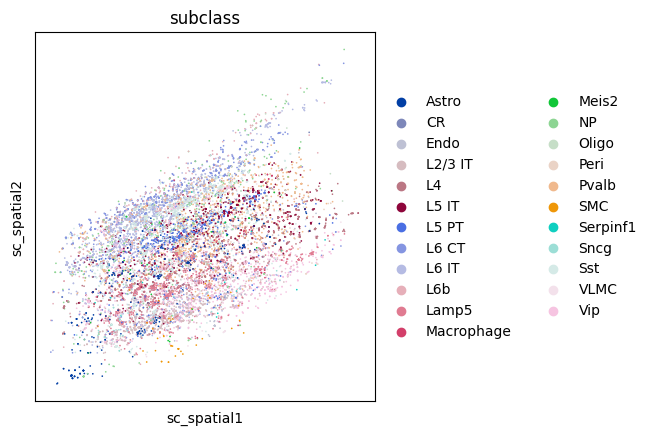

In [5]:
sc_expr = sparse.coo_matrix(raw_scrna_df[raw_shared_gene].values)
sp_expr = raw_spatial_df[raw_shared_gene].values
loc     = osmFISH.obsm['spatial']
sc_loc = expLocImp(sc_expr, 
            sp_expr,
            loc,
            n_neighbors=6,
            l_kernel=2,
            autocorr_method='moranI',
            mapping_lowdim=128,
            lr=1e-5, weight_decay=1e-3, n_epochs=2000,
            device=device,
            seed=seed
            ) 

VISp_adata.obsm["sc_spatial"] = sc_loc # MinMaxScaler().fit_transform(sc_loc)
sc.pl.spatial(VISp_adata, basis="sc_spatial", color="subclass", spot_size=0.005)            

sq.gr.spatial_neighbors(VISp_adata,  spatial_key="sc_spatial", key_added="sc_spatial")
sq.gr.spatial_autocorr(
    VISp_adata,
    connectivity_key="sc_spatial_connectivities",
    mode="moran",
    # n_perms=100,
    n_jobs=10,
)
                      

In [6]:
np.unique(VISp_adata.obs['class'], return_counts=True)

(array(['Endothelial', 'GABAergic', 'Glutamatergic', 'Non-Neuronal'],
       dtype=object),
 array([ 181, 6125, 7366,  577]))

(array([ 324., 1060., 2462., 2995., 2572., 2112., 1419.,  859.,  373.,
         73.]), array([-0.00296387,  0.08977394,  0.18251175,  0.27524954,  0.36798733,
        0.46072516,  0.5534629 ,  0.6462008 ,  0.73893857,  0.83167636,
        0.92441416], dtype=float32), <BarContainer object of 10 artists>)


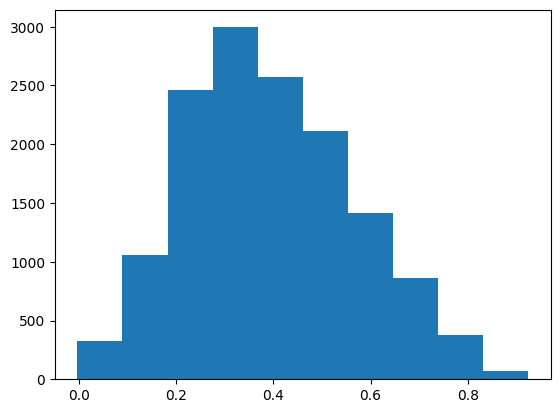

(array([  21.,   40.,  128.,  725., 2919., 3722., 2979., 2507., 1100.,
         108.]),
 array([-0.00276921,  0.09809402,  0.19895725,  0.29982048,  0.4006837 ,
         0.5015469 ,  0.60241014,  0.7032734 ,  0.80413663,  0.90499985,
         1.0058631 ], dtype=float32),
 <BarContainer object of 10 artists>)

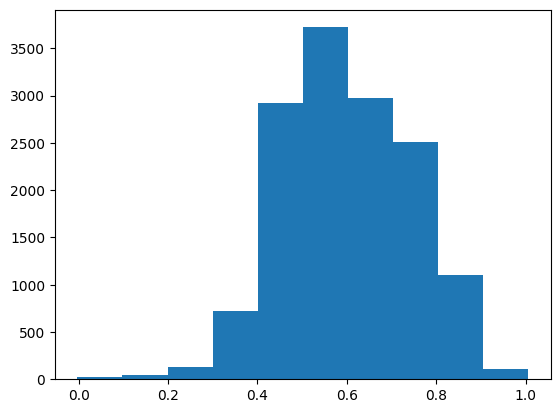

In [7]:
from matplotlib import pyplot as plt
print(plt.hist(sc_loc[:, 0])); plt.show(); plt.hist(sc_loc[:, 1])

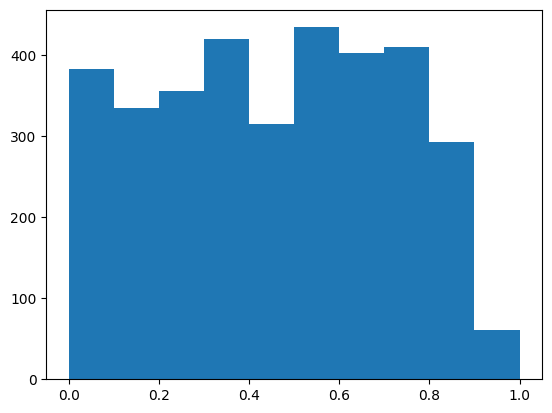

(array([ 48.,  69., 162., 279., 531., 706., 628., 499., 339., 144.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

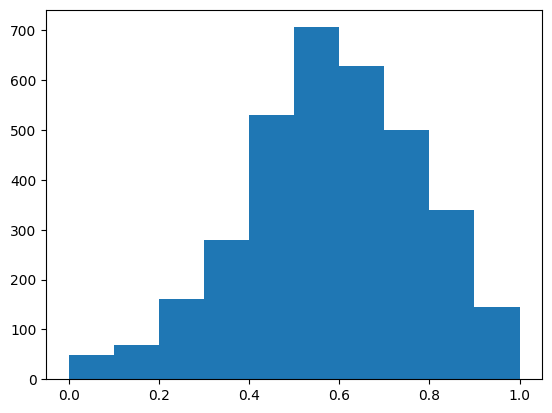

In [8]:
from matplotlib import pyplot as plt
plt.hist(osmFISH.obsm['spatial'][:, 0]); plt.show(); plt.hist(osmFISH.obsm['spatial'][:, 1])

2022-12-23 10:53:13,023 - harmonypy - INFO - Iteration 1 of 10
2022-12-23 10:53:22,685 - harmonypy - INFO - Iteration 2 of 10
2022-12-23 10:53:32,876 - harmonypy - INFO - Converged after 2 iterations


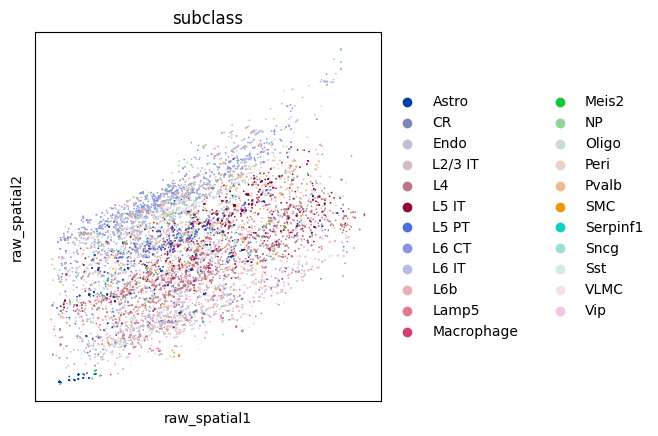

In [9]:
from sklearn.neighbors import  NearestNeighbors
from scipy.special import softmax
K = 2
adata = sc.AnnData(np.vstack([VISp_adata[:,osmFISH.var_names].X, osmFISH.X]))
adata.obs['batch'] = ["a"] * VISp_adata.shape[0] + ['b'] * osmFISH.shape[0]
sc.pp.pca(adata)
sc.external.pp.harmony_integrate(adata, 'batch')

emb_sc = adata.obsm['X_pca_harmony'][:sc_expr.shape[0], :]
emb_sp = adata.obsm['X_pca_harmony'][sc_expr.shape[0]:, :]
nn = NearestNeighbors(n_neighbors=K, metric='cosine', n_jobs=20)
nn.fit(emb_sp)
dists, nbs = nn.kneighbors(emb_sc, K, True)
sc_loc = np.expand_dims(softmax(-dists, axis=-1),1) @ loc[nbs]

VISp_adata.obsm["raw_spatial"] = sc_loc.squeeze() # MinMaxScaler().fit_transform(sc_loc)
sc.pl.spatial(VISp_adata, basis="raw_spatial", color="subclass", spot_size=0.005)


In [10]:
VISp_adata

AnnData object with n_obs × n_vars = 14249 × 34617
    obs: 'sample_name', 'sample_id', 'sample_type', 'organism', 'donor', 'sex', 'age_days', 'eye_condition', 'genotype', 'driver_lines', 'reporter_lines', 'brain_hemisphere', 'brain_region', 'brain_subregion', 'injection_label_direction', 'injection_primary', 'injection_secondary', 'injection_tract', 'injection_material', 'injection_exclusion_criterion', 'facs_date', 'facs_container', 'facs_sort_criteria', 'rna_amplification_set', 'library_prep_set', 'library_prep_avg_size_bp', 'seq_name', 'seq_tube', 'seq_batch', 'total_reads', 'percent_exon_reads', 'percent_intron_reads', 'percent_intergenic_reads', 'percent_rrna_reads', 'percent_mt_exon_reads', 'percent_reads_unique', 'percent_synth_reads', 'percent_ecoli_reads', 'percent_aligned_reads_total', 'complexity_cg', 'genes_detected_cpm_criterion', 'genes_detected_fpkm_criterion', 'tdt_cpm', 'gfp_cpm', 'class', 'subclass', 'cluster', 'confusion_score', 'cluster_correlation', 'core_intermed

In [11]:
sq.gr.spatial_neighbors(osmFISH,  spatial_key="spatial", key_added="spatial")
sq.gr.spatial_autocorr(
    osmFISH,
    connectivity_key="spatial_connectivities",
    mode="moran",
    # n_perms=100,
    n_jobs=10,
)
osmFISH.uns["moranI"]

,I,pval_norm,var_norm,pval_norm_fdr_bh
Rorb,0.719186,0.0,0.0001,0.0
Syt6,0.518499,0.0,0.0001,0.0
Kcnip2,0.451954,0.0,0.0001,0.0
Lamp5,0.449901,0.0,0.0001,0.0
Cpne5,0.428638,0.0,0.0001,0.0
Gfap,0.413927,0.0,0.0001,0.0
Plp1,0.352072,0.0,0.0001,0.0
Ctps,0.280360,0.0,0.0001,0.0
Tbr1,0.271218,0.0,0.0001,0.0
Apln,0.214584,0.0,0.0001,0.0


In [12]:
sq.gr.spatial_neighbors(VISp_adata,  spatial_key="raw_spatial", key_added="raw_spatial")
sq.gr.spatial_autocorr(
    VISp_adata,
    connectivity_key="raw_spatial_connectivities",
    mode="moran",
    # n_perms=100,
    n_jobs=10,
)
VISp_adata.uns["moranI"].loc[osmFISH.var_names]

,I,pval_norm,var_norm,pval_norm_fdr_bh
Gene,,,,
Gad2,0.619460,0.000000,0.000026,0.000000
Slc32a1,0.588707,0.000000,0.000026,0.000000
Crhbp,0.534277,0.000000,0.000026,0.000000
Cnr1,0.551366,0.000000,0.000026,0.000000
Vip,0.697508,0.000000,0.000026,0.000000
Cpne5,0.515758,0.000000,0.000026,0.000000
Pthlh,0.591447,0.000000,0.000026,0.000000
Crh,0.679761,0.000000,0.000026,0.000000
Tbr1,0.548214,0.000000,0.000026,0.000000


In [13]:
VISp_adata_cp = VISp_adata.copy()
sq.gr.spatial_neighbors(VISp_adata_cp,  spatial_key="sc_spatial", key_added="sc_spatial")
sq.gr.spatial_autocorr(
    VISp_adata_cp,
    connectivity_key="sc_spatial_connectivities",
    mode="moran",
    # n_perms=100,
    n_jobs=10,
)
VISp_adata_cp.uns["moranI"].loc[osmFISH.var_names]

,I,pval_norm,var_norm,pval_norm_fdr_bh
Gene,,,,
Gad2,0.216802,0.000000,0.000026,0.000000
Slc32a1,0.193314,0.000000,0.000026,0.000000
Crhbp,0.169420,0.000000,0.000026,0.000000
Cnr1,0.260189,0.000000,0.000026,0.000000
Vip,0.239066,0.000000,0.000026,0.000000
Cpne5,0.359561,0.000000,0.000026,0.000000
Pthlh,0.186150,0.000000,0.000026,0.000000
Crh,0.251097,0.000000,0.000026,0.000000
Tbr1,0.273657,0.000000,0.000026,0.000000


In [14]:
from sklearn.metrics import mean_squared_error
print(mean_squared_error(osmFISH.uns['moranI'].I, VISp_adata_cp.uns['moranI'].loc[osmFISH.uns['moranI'].index].I))
print(mean_squared_error(osmFISH.uns['moranI'].I, VISp_adata.uns['moranI'].loc[osmFISH.uns['moranI'].index].I))

0.005170091874445
0.07300946619301303


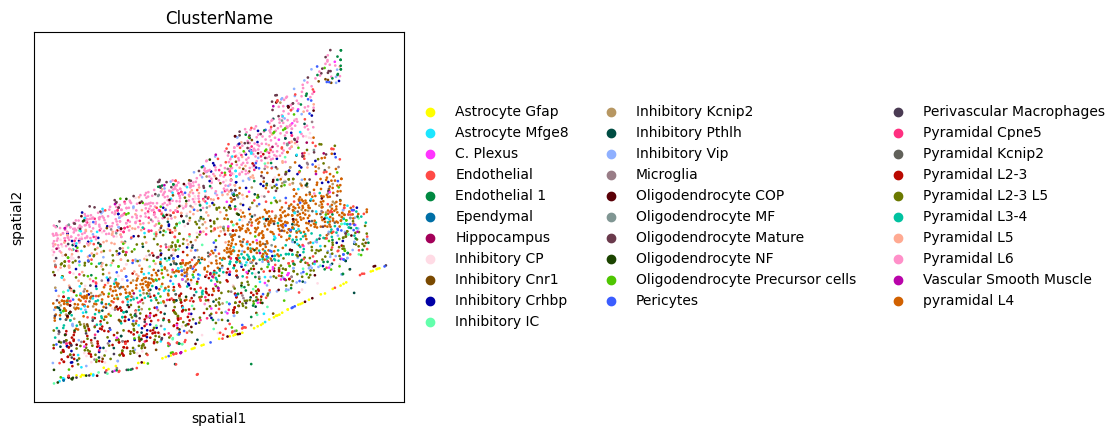

In [15]:
sc.pl.spatial(osmFISH, color="ClusterName", basis="spatial", spot_size=0.008)

In [22]:
VISp_adata


AnnData object with n_obs × n_vars = 14249 × 34617
    obs: 'sample_name', 'sample_id', 'sample_type', 'organism', 'donor', 'sex', 'age_days', 'eye_condition', 'genotype', 'driver_lines', 'reporter_lines', 'brain_hemisphere', 'brain_region', 'brain_subregion', 'injection_label_direction', 'injection_primary', 'injection_secondary', 'injection_tract', 'injection_material', 'injection_exclusion_criterion', 'facs_date', 'facs_container', 'facs_sort_criteria', 'rna_amplification_set', 'library_prep_set', 'library_prep_avg_size_bp', 'seq_name', 'seq_tube', 'seq_batch', 'total_reads', 'percent_exon_reads', 'percent_intron_reads', 'percent_intergenic_reads', 'percent_rrna_reads', 'percent_mt_exon_reads', 'percent_reads_unique', 'percent_synth_reads', 'percent_ecoli_reads', 'percent_aligned_reads_total', 'complexity_cg', 'genes_detected_cpm_criterion', 'genes_detected_fpkm_criterion', 'tdt_cpm', 'gfp_cpm', 'class', 'subclass', 'cluster', 'confusion_score', 'cluster_correlation', 'core_intermed

In [24]:
VISp_adata_cp

AnnData object with n_obs × n_vars = 14249 × 34617
    obs: 'sample_name', 'sample_id', 'sample_type', 'organism', 'donor', 'sex', 'age_days', 'eye_condition', 'genotype', 'driver_lines', 'reporter_lines', 'brain_hemisphere', 'brain_region', 'brain_subregion', 'injection_label_direction', 'injection_primary', 'injection_secondary', 'injection_tract', 'injection_material', 'injection_exclusion_criterion', 'facs_date', 'facs_container', 'facs_sort_criteria', 'rna_amplification_set', 'library_prep_set', 'library_prep_avg_size_bp', 'seq_name', 'seq_tube', 'seq_batch', 'total_reads', 'percent_exon_reads', 'percent_intron_reads', 'percent_intergenic_reads', 'percent_rrna_reads', 'percent_mt_exon_reads', 'percent_reads_unique', 'percent_synth_reads', 'percent_ecoli_reads', 'percent_aligned_reads_total', 'complexity_cg', 'genes_detected_cpm_criterion', 'genes_detected_fpkm_criterion', 'tdt_cpm', 'gfp_cpm', 'class', 'subclass', 'cluster', 'confusion_score', 'cluster_correlation', 'core_intermed

I                   0.271218
pval_norm           0.000000
var_norm            0.000100
pval_norm_fdr_bh    0.000000
Name: Tbr1, dtype: float64
AnnData object with n_obs × n_vars = 3405 × 1
    obsm: 'spatial'


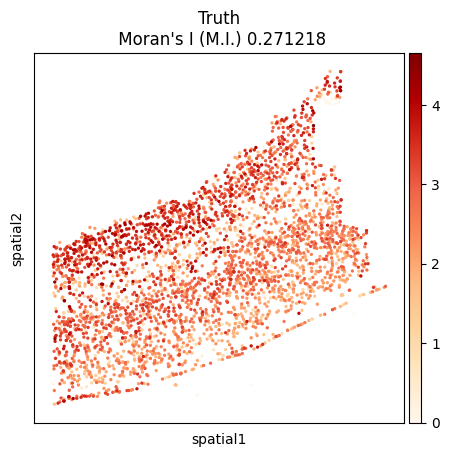

I                   0.548214
pval_norm           0.000000
var_norm            0.000026
pval_norm_fdr_bh    0.000000
Name: Tbr1, dtype: float64
AnnData object with n_obs × n_vars = 14249 × 1
    obsm: 'sc_spatial', 'raw_spatial'


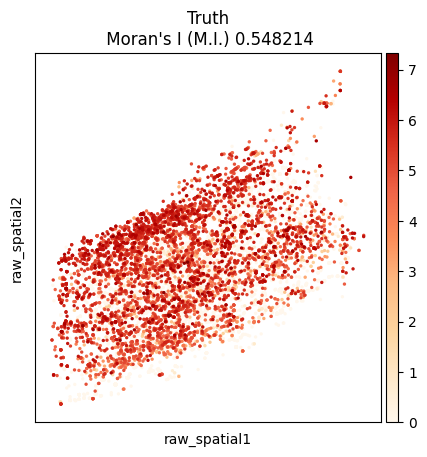

I                   0.273657
pval_norm           0.000000
var_norm            0.000026
pval_norm_fdr_bh    0.000000
Name: Tbr1, dtype: float64
AnnData object with n_obs × n_vars = 14249 × 1
    obsm: 'sc_spatial', 'raw_spatial'


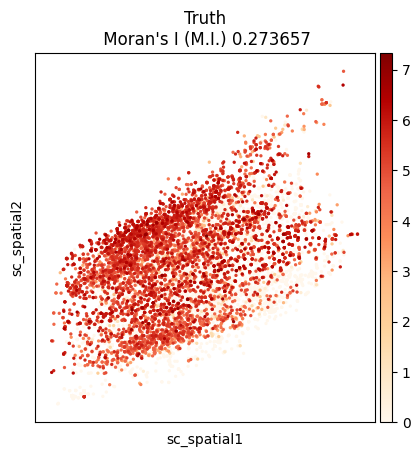

In [31]:
def plot(gene, spa_adata, spa_key):
    exprs = [spa_adata[:, gene].X.toarray().flatten()]
    titles = [f"Truth\n Moran's I (M.I.) {spa_adata.uns['moranI'].loc[gene].I:.6f}"]
    # sc.pl.spatial(spa_adata, color=[gene], spot_size=0.1, title='Truth')
    print(spa_adata.uns['moranI'].loc[gene])
    
    tmp_adata = sc.AnnData(np.array(exprs).T)
    tmp_adata.obsm = spa_adata.obsm
    tmp_adata.var_names = titles
    
    print(tmp_adata)
    sc.pl.spatial(tmp_adata, color=titles, basis=spa_key, spot_size=0.01, title=titles, color_map='OrRd')
plot("Tbr1", osmFISH, spa_key='spatial')
plot("Tbr1", VISp_adata, spa_key='raw_spatial')
plot("Tbr1", VISp_adata_cp, spa_key='sc_spatial')

I                   0.449901
pval_norm           0.000000
var_norm            0.000100
pval_norm_fdr_bh    0.000000
Name: Lamp5, dtype: float64
AnnData object with n_obs × n_vars = 3405 × 1
    obsm: 'spatial'


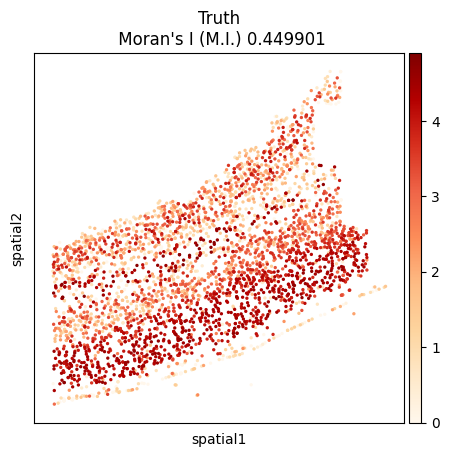

I                   0.622605
pval_norm           0.000000
var_norm            0.000026
pval_norm_fdr_bh    0.000000
Name: Lamp5, dtype: float64
AnnData object with n_obs × n_vars = 14249 × 1
    obsm: 'sc_spatial', 'raw_spatial'


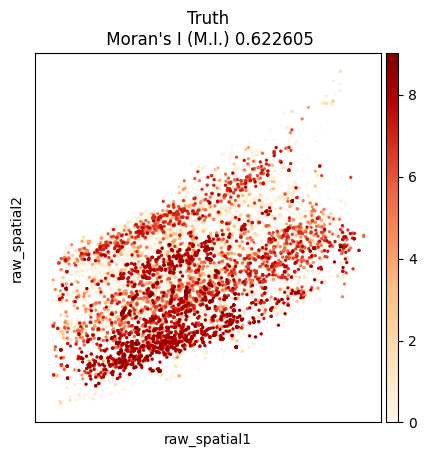

I                   0.415601
pval_norm           0.000000
var_norm            0.000026
pval_norm_fdr_bh    0.000000
Name: Lamp5, dtype: float64
AnnData object with n_obs × n_vars = 14249 × 1
    obsm: 'sc_spatial', 'raw_spatial'


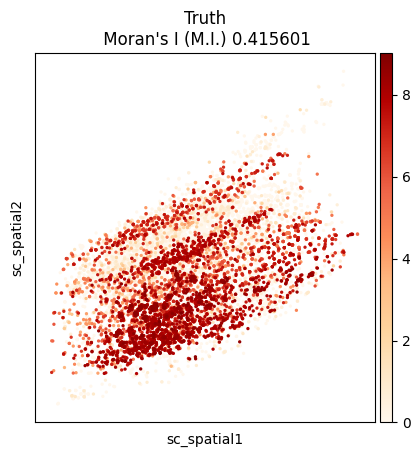

In [32]:
def plot(gene, spa_adata, spa_key):
    exprs = [spa_adata[:, gene].X.toarray().flatten()]
    titles = [f"Truth\n Moran's I (M.I.) {spa_adata.uns['moranI'].loc[gene].I:.6f}"]
    # sc.pl.spatial(spa_adata, color=[gene], spot_size=0.1, title='Truth')
    print(spa_adata.uns['moranI'].loc[gene])
    
    tmp_adata = sc.AnnData(np.array(exprs).T)
    tmp_adata.obsm = spa_adata.obsm
    tmp_adata.var_names = titles
    
    print(tmp_adata)
    sc.pl.spatial(tmp_adata, color=titles, basis=spa_key, spot_size=0.01, title=titles, color_map='OrRd')
plot("Lamp5", osmFISH, spa_key='spatial')
plot("Lamp5", VISp_adata, spa_key='raw_spatial')
plot("Lamp5", VISp_adata_cp, spa_key='sc_spatial')

I                   0.719186
pval_norm           0.000000
var_norm            0.000100
pval_norm_fdr_bh    0.000000
Name: Rorb, dtype: float64
AnnData object with n_obs × n_vars = 3405 × 1
    obsm: 'spatial'


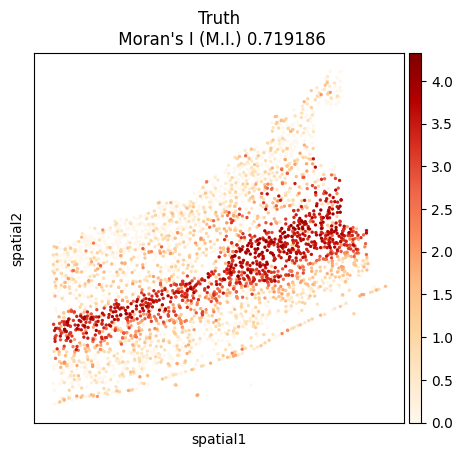

I                   0.601219
pval_norm           0.000000
var_norm            0.000026
pval_norm_fdr_bh    0.000000
Name: Rorb, dtype: float64
AnnData object with n_obs × n_vars = 14249 × 1
    obsm: 'sc_spatial', 'raw_spatial'


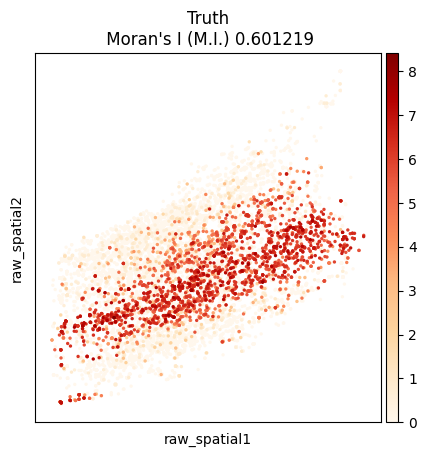

I                   0.515292
pval_norm           0.000000
var_norm            0.000026
pval_norm_fdr_bh    0.000000
Name: Rorb, dtype: float64
AnnData object with n_obs × n_vars = 14249 × 1
    obsm: 'sc_spatial', 'raw_spatial'


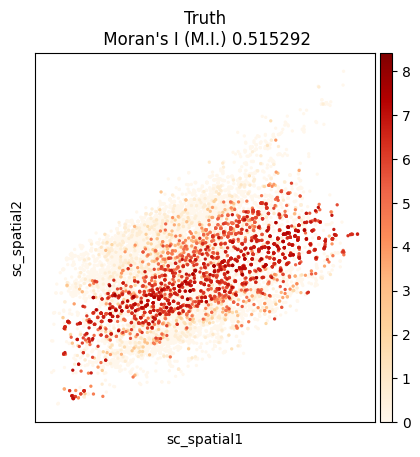

NameError: name 'Rorb' is not defined

In [33]:
def plot(gene, spa_adata, spa_key):
    exprs = [spa_adata[:, gene].X.toarray().flatten()]
    titles = [f"Truth\n Moran's I (M.I.) {spa_adata.uns['moranI'].loc[gene].I:.6f}"]
    # sc.pl.spatial(spa_adata, color=[gene], spot_size=0.1, title='Truth')
    print(spa_adata.uns['moranI'].loc[gene])
    
    tmp_adata = sc.AnnData(np.array(exprs).T)
    tmp_adata.obsm = spa_adata.obsm
    tmp_adata.var_names = titles
    
    print(tmp_adata)
    sc.pl.spatial(tmp_adata, color=titles, basis=spa_key, spot_size=0.01, title=titles, color_map='OrRd')
plot("Rorb", osmFISH, spa_key='spatial')
plot("Rorb", VISp_adata, spa_key='raw_spatial')
plot("Rorb", VISp_adata_cp, spa_key='sc_spatial')
